In [1]:
import numpy as np
import matplotlib.pyplot as plt

def get_reflection_rate(d, n, e0, e1):
    theta_s = np.arccos(np.dot(d,-n)) # 入射角

    # 真空から第一層への屈折角   田中M論 式(2.9) スネルの法則
    theta_I =  np.arccos(np.sqrt(1-e0/e1*(np.sin(theta_s))**2))

    # 反射率の計算 (田中M論より)
    Rtm = np.tan(theta_s-theta_I)/np.tan(theta_s+theta_I) # TMモード
    Rte = -np.sin(theta_s-theta_I)/np.sin(theta_s+theta_I) # TEモード

    return Rtm, Rte

def get_default_param(target):

    match target:
        case "moon":
            #H_obs = 100e3       # 観測者の高度[m] (Kaguya)
            #D_moon = 1*1e3      # 表層から地下構造までのレゴリスリス層(第一層)の厚さ[m]
            #R_moon = 1737400.0  # 月の半径[m]
            e1 = 4.0            # レゴリス層(第一層)の比誘電率
            e2 = 8.0            # レゴリス層の下の地下構造(第二層)の比誘電率
            #tandelta = 0.0125   # レゴリス層(第一層)の損失角

        case "ganymede":
            #H_obs = 500e3       # 観測者の高度[m] (JUICE)
            #D_moon = 1*1e3      # 表層から地下構造までのレゴリスリス層(第一層)の厚さ[m]
            #R_moon = 5268000.0/2.0  # ガニメデの半径[m]
            e1 = 3.0            # 第一層の比誘電率
            e2 = 87.0           # 第二層の比誘電率
            #tandelta = 0.0      # 第一層の損失角
    
    return e1, e2 #H_obs, D_moon, R_moon, e1, e2, tandelta

/tmp/ipykernel_3219303/1723020637.py:11: RuntimeWarning: invalid value encountered in scalar divide
  Rtm = np.tan(theta_s-theta_I)/np.tan(theta_s+theta_I) # TMモード
/tmp/ipykernel_3219303/1723020637.py:12: RuntimeWarning: invalid value encountered in scalar divide
  Rte = -np.sin(theta_s-theta_I)/np.sin(theta_s+theta_I) # TEモード


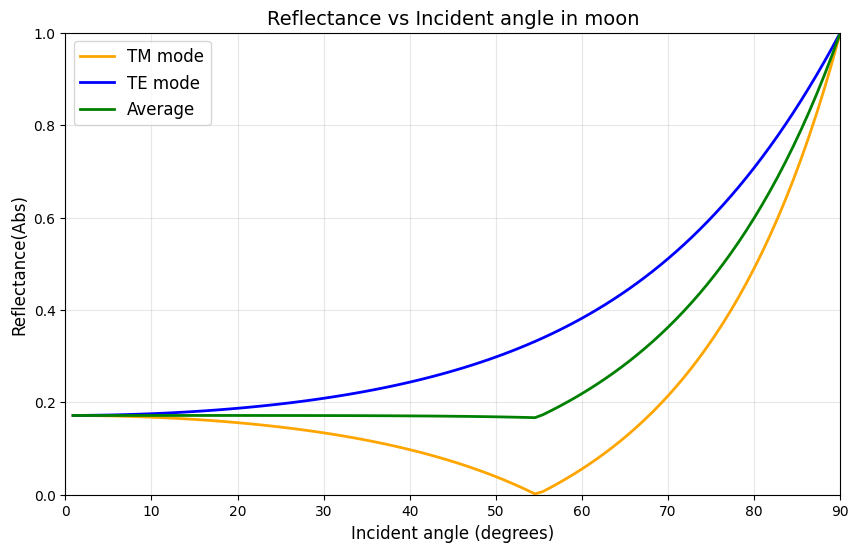

In [4]:
# 半径1の円にy軸正方向から平面波を入射
# 入射方向ベクトル (y軸正方向から)
d = np.array([0, -1, 0])

# パラメータ設定 e0: 真空の誘電率, e1: 氷層の誘電率
target = "moon" # "moon" or "ganymede"

e0, e1 = get_default_param(target)

# 入射角の範囲を設定 (0度から90度)
theta_s_range = np.linspace(0, np.pi/2, 100)

# 反射率を計算
Rtm_list = []
Rte_list = []

for theta_s in theta_s_range:
    # 円の表面法線ベクトル (入射角theta_sに対応)
    n = np.array([np.sin(theta_s), np.cos(theta_s), 0])
    
    Rtm, Rte = get_reflection_rate(d, n, e0, e1)
    Rtm_list.append(np.absolute(Rtm))  # 反射率 (パワー)
    Rte_list.append(np.absolute(Rte))  # 反射率 (パワー)

Rave_list = [(Rtm + Rte)/2 for Rtm, Rte in zip(Rtm_list, Rte_list)]

# 描画
plt.figure(figsize=(10, 6))
plt.plot(np.degrees(theta_s_range), Rtm_list, label='TM mode', linewidth=2, color="orange")
plt.plot(np.degrees(theta_s_range), Rte_list, label='TE mode', linewidth=2, color="blue")
plt.plot(np.degrees(theta_s_range), Rave_list, label='Average', linewidth=2, color="green")
plt.xlabel('Incident angle (degrees)', fontsize=12)
plt.ylabel('Reflectance(Abs)', fontsize=12)
plt.title(f'Reflectance vs Incident angle in {target}', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.xlim(0, 90)
plt.ylim(0, 1)

plt.savefig(f'./output_refl/reflectance_vs_incident_angle_{target}.png', dpi=300)
plt.show()

In [20]:
spe_deg = 80
spe_rad = spe_deg * np.pi / 180

theta_I =  np.arccos(np.sqrt(1-e0/e1*(np.sin(spe_rad))**2))
Rte = -np.sin(spe_rad-theta_I)/np.sin(spe_rad+theta_I)
Rtm = np.tan(spe_rad-theta_I)/np.tan(spe_rad+theta_I)

print(Rte, Rtm)

-0.9364856619430588 -0.025029065638711698
